In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests
import seaborn as sns
import plotly.graph_objects as go 
import pandas as pd

# Database Description
* I used the City of Toronto's Daily Shelter & Overnight Service Occupancy & Capacity databased (2025)
* URL: https://open.toronto.ca/dataset/daily-shelter-overnight-service-occupancy-capacity/
* This data set provides a daily list of active overnight shelter and allied services in the Toronto Shelter and Support Services division's Shelter Management Information System (SMIS) database. The data provides daily updated information about shelter and overnight service programs administered by TSSS including the program's operator, location, classification, occupancy and capacity.

# Visualization Purpose

* I will create visualiztion correlating between Month and the average occupancy rate in ALL shelters in the city of Toronto - which are devided into two type: bed shelters for individuals (coded as "OCCUPANCY_RATE_BEDS") and room shelters for families ("OCCUPANCY_RATE_ROOMS)
* Month variable does not  exit in my dataset, therefore I will create a month variable from ("OCCUPANCY_DATE")
* Every date includes many observations of all bed/room shelters in Toronto, there for I will have to create a new variable showing the avarage bed occupancy rate per date. 

In [2]:
df = pd.read_csv('C:/Users/ofirs/OneDrive/Desktop/DSI PRACTICE/visualization/02_activities/assignments/daily-shelter-overnight-service-occupancy-capacity-2025.csv')
print (df)

         _id OCCUPANCY_DATE  ORGANIZATION_ID  \
0          1     01/01/2025                5   
1          2     01/01/2025               15   
2          3     01/01/2025               35   
3          4     01/01/2025               14   
4          5     01/01/2025               10   
...      ...            ...              ...   
51538  51539     31/12/2025               24   
51539  51540     31/12/2025                8   
51540  51541     31/12/2025                1   
51541  51542     31/12/2025                1   
51542  51543     31/12/2025               13   

                                       ORGANIZATION_NAME  SHELTER_ID  \
0                                 The Scott Mission Inc.           8   
1                                    Homes First Society          24   
2      Margaret's Housing and Community Support Services          67   
3                Christie Ossington Neighbourhood Centre          22   
4                               Good Shepherd Ministries       

In [3]:
# I will now create the new variables [BOR= Bed Occupancy Rate]; [ROR = Room Occupancy  Rate] and we will define a new variable for date

In [4]:
df['OCCUPANCY_DATE'] = pd.to_datetime(df['OCCUPANCY_DATE'], format='%d/%m/%Y')
df['month'] = df['OCCUPANCY_DATE'].dt.month

In [5]:
monthly_avg_BOR= df.groupby('month')['OCCUPANCY_RATE_BEDS'].mean()
monthly_avg_ROR= df.groupby('month')['OCCUPANCY_RATE_ROOMS'].mean()

print (monthly_avg_BOR,  monthly_avg_ROR)

month
1     95.232565
2     94.511219
3     95.359168
4     96.184267
5     96.555752
6     94.648372
7     93.650000
8     94.917336
9     96.682270
10    96.710951
11    93.691325
12    93.481048
Name: OCCUPANCY_RATE_BEDS, dtype: float64 month
1     98.799513
2     98.479675
3     98.111803
4     98.746901
5     98.871190
6     99.200770
7     99.215100
8     99.290183
9     99.377434
10    99.615696
11    99.484650
12    98.965967
Name: OCCUPANCY_RATE_ROOMS, dtype: float64


In [6]:
# now I will create a new data dicitnary to create a new frame with the new veriable. This new dataframe will use me for my visualiztion
# I will make sure to "force" my data frme into 12 rows- use the reindex method with the series  argument "range (1, 13,1)". then I will use reset index to seperate
# between the index and month - making month a variable

In [7]:
new_df = pd.DataFrame({
    'room_occ': monthly_avg_ROR,
    'bed_occ': monthly_avg_BOR, 
}) 

new_df = new_df.reindex(range(1, 13,1))  

new_df = new_df.reset_index().rename(columns={'index': 'month'})

print (new_df)

    month   room_occ    bed_occ
0       1  98.799513  95.232565
1       2  98.479675  94.511219
2       3  98.111803  95.359168
3       4  98.746901  96.184267
4       5  98.871190  96.555752
5       6  99.200770  94.648372
6       7  99.215100  93.650000
7       8  99.290183  94.917336
8       9  99.377434  96.682270
9      10  99.615696  96.710951
10     11  99.484650  93.691325
11     12  98.965967  93.481048


In [8]:
# now I will visualize the relationships when X is defined as the date and Y is the rate; 
# since I want to show the different trends between room and bed occupation by month- thus, I will use a barplot for bed occupation and line for room

In [9]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

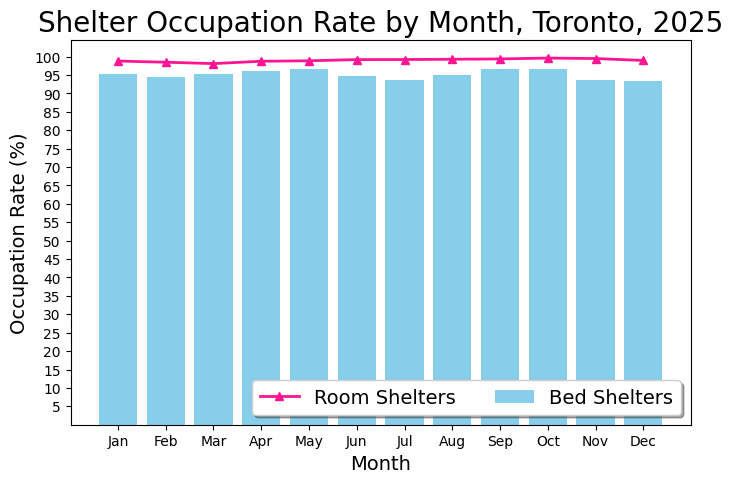

In [15]:

fig, ax = plt.subplots(figsize=(8, 5))

# I will create a bar plot for bed and line plot for room so it is possible to discern differences 

ax.bar(new_df['month'], new_df['bed_occ'], color='skyblue', label='Bed Shelters')
ax.plot(new_df['month'], new_df['room_occ'], color='deeppink', label='Room Shelters', linewidth = 2, marker= "^")
font1 = {'family':'DejaVu Sans','color':'black','size':20} # defining fonts
font2 = {'family':'DejaVu Sans','color':'black','size':14} 
plt.xticks(fontname= "DejaVu Sans") #defining tick fonts 
plt.yticks(fontname= "DejaVu Sans")
ax.set_title('Shelter Occupation Rate by Month, Toronto, 2025', font1)
ax.set_ylabel('Occupation Rate (%)', font2)
ax.set_xlabel('Month',font2)
ax.set_xticks(np.arange(1, 13, 1)) # adding more ticks for x axes
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']) #changing month mumber to names to make the vis readable
ax.set_yticks(np.arange(5, 105, 5)) # adding ticks 
ax.legend(loc='lower right',  #place the legend to not compromise interpretability
        frameon = True,  
        ncol = 2,
        prop={'family': 'DejaVu Sans', 'size': 14},
        shadow = True )

plt.style.use('seaborn-v0_8-colorblind') #ensuring accessibility of my data
plt.show()
